# HandReachDense — PPO

Capítulos 1–5. El informe del capítulo 6 y la ejecución real en Colab quedan pendientes de la entrega académica.

## Capítulo 1 — Librerías, bootstrap y variables transversales

Python 3.12. Instalación solo en Colab; entorno local aislado preparado según README. Pins verificados localmente, sin afirmar validación Colab.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
DEPENDENCIES = {
    "gymnasium-robotics": "1.4.2", "gymnasium": "1.3.0", "mujoco": "3.2.7",
    "stable-baselines3": "2.9.0", "torch": "2.14.0", "numpy": "2.5.3",
    "pandas": "3.0.5", "matplotlib": "3.11.2", "pillow": "12.3.0",
    "imageio": "2.37.4", "imageio-ffmpeg": "0.6.0",
}
if IN_COLAB:
    os.environ["MUJOCO_GL"] = "egl"
    subprocess.check_call([sys.executable, "-m", "pip", "install", *[
        f"{name}=={version}" for name, version in DEPENDENCIES.items()
    ]])


In [2]:
import hashlib
import importlib.metadata
import json
import platform
import random
import time
from datetime import datetime, timezone

import gymnasium as gym
import gymnasium_robotics
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageDraw, ImageFont
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor

gym.register_envs(gymnasium_robotics)
VERSIONS = {name: importlib.metadata.version(name) for name in DEPENDENCIES}
assert VERSIONS == DEPENDENCIES, (VERSIONS, DEPENDENCIES)
CONFIG = {
    "env_id": "HandReachDense-v3", "algorithm": "PPO", "policy": "MultiInputPolicy",
    "profile": "full", "train_seed": 42, "device": "cpu", "torch_threads": 1,
    "baseline_seeds": list(range(101, 121)), "tuning_seeds": list(range(201, 211)),
    "selection_seeds": list(range(201, 211)), "final_eval_seeds": list(range(1001, 1011)),
    "probe_seeds": list(range(5001, 5101)), "reload_seeds": [401, 402],
    "video_seed": 301, "intermediate_timesteps": 500_000, "video_fps": 25, "video_size": 480,
    "success_definition": "success_final", "target_success": 0.80,
    "eval_freq": 50_000, "checkpoint_freq": 100_000, "rolling_window": 100,
    "profiles": {"smoke": {"timesteps": 8_192}, "full": {"timesteps": 1_000_000}},
    "ppo": {"learning_rate": 3e-4, "n_steps": 2048, "batch_size": 256,
            "n_epochs": 10, "gamma": 0.99, "gae_lambda": 0.95, "clip_range": 0.2,
            "ent_coef": 0.0, "vf_coef": 0.5, "max_grad_norm": 0.5, "normalize_advantage": True},
    "tuning_adjustment_1": {"learning_rate": 3e-5, "clip_range": 0.1},
    "log_std_init": 0.0, "tuning_adjustment_2_log_std_init": -1.0,
    "net_arch": {"pi": [256, 256], "vf": [256, 256]},
}
MODEL_FOLDER = "3-HandReachDense"
PROJECT_ROOT = Path("/content") if IN_COLAB else Path.cwd().resolve()
MODEL_ROOT = PROJECT_ROOT if PROJECT_ROOT.name == MODEL_FOLDER else PROJECT_ROOT / MODEL_FOLDER
MODEL_DIR = MODEL_ROOT / "models"
VIDEO_DIR = MODEL_ROOT / "videos"
RESULTS_DIR = MODEL_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
RUNS_DIR = MODEL_ROOT / "runs"
FINAL_MODEL = MODEL_DIR / "hand_reach_ppo.zip"
METADATA_PATH = FINAL_MODEL.with_suffix(".metadata.json")
for directory in (MODEL_DIR, VIDEO_DIR, RESULTS_DIR, FIGURES_DIR, RUNS_DIR):
    directory.mkdir(parents=True, exist_ok=True)
random.seed(CONFIG["train_seed"])
np.random.seed(CONFIG["train_seed"])
torch.manual_seed(CONFIG["train_seed"])
torch.set_num_threads(CONFIG["torch_threads"])
print(json.dumps({"versions": VERSIONS, "python": platform.python_version(),
                  "platform": platform.platform(), "machine": platform.machine(),
                  "device": CONFIG["device"], "cuda": torch.cuda.is_available(),
                  "mps": torch.backends.mps.is_available()}, indent=2))


AdroitHandRelocateDense-v1, AdroitHandHammerDense-v1, AdroitHandDoorDense-v1 environment's reward functions were updated in v1.2.1 without an environment version update. Therefore, use gymnasium-robotics==1.2.0 for v1 reproducibility or use v2 in gymnasium-robotics>=1.4.3. See https://github.com/Farama-Foundation/Gymnasium-Robotics/pull/220 for more details


{
  "versions": {
    "gymnasium-robotics": "1.4.2",
    "gymnasium": "1.3.0",
    "mujoco": "3.2.7",
    "stable-baselines3": "2.9.0",
    "torch": "2.14.0",
    "numpy": "2.5.3",
    "pandas": "3.0.5",
    "matplotlib": "3.11.2",
    "pillow": "12.3.0",
    "imageio": "2.37.4",
    "imageio-ffmpeg": "0.6.0"
  },
  "python": "3.12.13",
  "platform": "macOS-26.6.2-arm64-arm-64bit",
  "machine": "arm64",
  "device": "cpu",
  "cuda": false,
  "mps": true
}


{
  "environment_id": "HandReachDense-v3",
  "entry_point": "gymnasium_robotics.envs.shadow_dexterous_hand.reach:MujocoHandReachEnv",
  "max_episode_steps": 50,
  "action_space": "Box(-1.0, 1.0, (20,), float32)",
  "observation_space": "Dict('achieved_goal': Box(-inf, inf, (15,), float64), 'desired_goal': Box(-inf, inf, (15,), float64), 'observation': Box(-inf, inf, (63,), float64))",
  "n_substeps": 20,
  "timestep": 0.002,
  "dt": 0.04,
  "distance_threshold": 0.01,
  "relative_control": false,
  "reward_type": "dense",
  "actuators": 20,
  "qpos_count": 24,
  "qvel_count": 24,
  "actuator_ctrlrange": [
    [
      -0.489,
      0.14
    ],
    [
      -0.698,
      0.489
    ],
    [
      -0.349,
      0.349
    ],
    [
      0.0,
      1.571
    ],
    [
      0.0,
      1.571
    ],
    [
      -0.349,
      0.349
    ],
    [
      0.0,
      1.571
    ],
    [
      0.0,
      1.571
    ],
    [
      -0.349,
      0.349
    ],
    [
      0.0,
      1.571
    ],
    [
      0

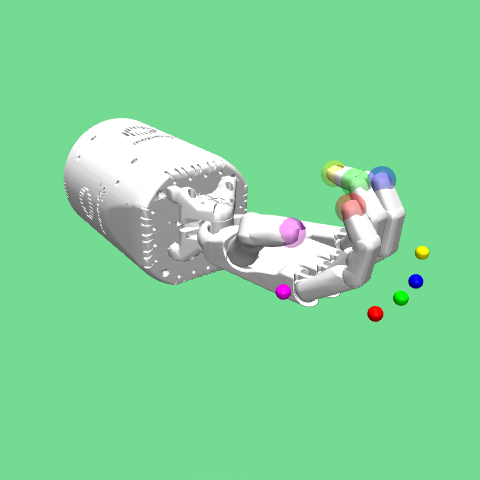

In [3]:
def make_env(seed, render=False):
    """Create the original environment and seed its spaces.

    Args:
        seed: Seed for environment and action/observation spaces.
        render: Whether to enable RGB rendering.

    Returns:
        A seeded Gymnasium environment with its original TimeLimit.
    """
    env = gym.make(CONFIG["env_id"], render_mode="rgb_array" if render else None,
                   width=CONFIG["video_size"], height=CONFIG["video_size"])
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    env.reset(seed=seed)
    return env


def write_json(path, value):
    """Write an inspectable JSON artifact.

    Args:
        path: Destination path.
        value: JSON-serializable data.
    """
    Path(path).write_text(json.dumps(value, indent=2, allow_nan=False) + "\n")


probe = make_env(CONFIG["train_seed"], render=True)
try:
    obs, _ = probe.reset(seed=CONFIG["train_seed"])
    raw = probe.unwrapped
    assert probe.action_space.shape == (20,)
    assert {k: v.shape for k, v in obs.items()} == {"observation": (63,), "achieved_goal": (15,), "desired_goal": (15,)}
    assert (raw.model.nq, raw.model.nv, raw.model.nu) == (24, 24, 20)
    np.testing.assert_allclose(obs["observation"][:24], raw.data.qpos)
    np.testing.assert_allclose(obs["observation"][24:48], raw.data.qvel)
    np.testing.assert_allclose(obs["observation"][48:], obs["achieved_goal"])
    assert not raw.relative_control and raw.reward_type == "dense"
    assert raw.n_substeps == 20 and np.isclose(raw.model.opt.timestep, 0.002)
    assert np.isclose(raw.dt, 0.04) and probe.spec.max_episode_steps == 50
    assert np.isclose(raw.distance_threshold, 0.01)
    goals, initial_count, fingers = [], 0, set()
    for seed in CONFIG["probe_seeds"]:
        obs, _ = probe.reset(seed=seed)
        goals.append(obs["desired_goal"].copy())
        changed = np.linalg.norm((obs["desired_goal"] - raw.initial_goal).reshape(5, 3), axis=1) > 1e-10
        if not changed.any():
            initial_count += 1
        else:
            assert changed[-1] and changed.sum() == 2
            fingers.add(int(np.flatnonzero(changed[:4])[0]))
    assert 0 < initial_count < len(goals) and fingers == {0, 1, 2, 3}
    first, _ = probe.reset(seed=CONFIG["train_seed"])
    second, _ = probe.reset(seed=CONFIG["train_seed"])
    np.testing.assert_array_equal(first["desired_goal"], second["desired_goal"])
    for step in range(1, 51):
        obs, reward, terminated, truncated, info = probe.step(probe.action_space.sample())
        distance = np.linalg.norm(obs["achieved_goal"] - obs["desired_goal"])
        assert np.isfinite(reward) and np.isclose(reward, -distance, atol=1e-6)
        assert bool(info["is_success"] > 0.5) == bool(distance < 0.01)
        assert not terminated and truncated == (step == 50)
    frame = probe.render()
    assert frame.shape == (CONFIG["video_size"], CONFIG["video_size"], 3)
    contract = {"environment_id": probe.spec.id, "entry_point": probe.spec.entry_point,
                "max_episode_steps": probe.spec.max_episode_steps,
                "action_space": str(probe.action_space), "observation_space": str(probe.observation_space),
                "n_substeps": raw.n_substeps, "timestep": raw.model.opt.timestep, "dt": raw.dt,
                "distance_threshold": raw.distance_threshold, "relative_control": raw.relative_control,
                "reward_type": raw.reward_type, "actuators": raw.model.nu,
                "qpos_count": raw.model.nq, "qvel_count": raw.model.nv,
                "actuator_ctrlrange": raw.model.actuator_ctrlrange.tolist(),
                "goal_probe": {"count": len(goals), "initial_goal_count": initial_count,
                               "selected_fingers": sorted(fingers), "seeds": CONFIG["probe_seeds"]},
                "versions": VERSIONS, "python": platform.python_version(),
                "execution_target": "colab" if IN_COLAB else "local",
                "reward_success_horizon_pass": True, "render_shape": list(frame.shape)}
    write_json(RESULTS_DIR / "runtime_contract.json", contract)
    print(json.dumps(contract, indent=2))
    display(Image.fromarray(frame))
finally:
    probe.close()


## Capítulo 2 — Definición del agente

La norma global de los cinco errores XYZ debe quedar por debajo de 0.01 m. El episodio dura 50 pasos aunque haya éxito. `success_final` es la métrica principal; `success_any` y `success_fraction` distinguen alcanzar de mantener. Se registran también el tipo de objetivo, errores por dedo y saturación de acciones. Seeds finales reservadas hasta después de la selección.

In [4]:
def evaluate_policy(model, seeds):
    """Evaluate complete episodes without learning or exploration noise.

    Args:
        model: Predict-compatible policy, or None for uniform random actions.
        seeds: Explicit evaluation seeds, separate from training.

    Returns:
        DataFrame with returns, success and geometric diagnostics per episode.
    """
    rows = []
    env = make_env(seeds[0])
    try:
        for seed in seeds:
            obs, _ = env.reset(seed=seed)
            env.action_space.seed(seed)
            goal_type = "initial_hold" if np.allclose(obs["desired_goal"], env.unwrapped.initial_goal, rtol=0, atol=1e-10) else "thumb_finger_meet"
            actions = []
            rewards, distances, successes = [], [], []
            terminated = truncated = False
            while not (terminated or truncated):
                action = env.action_space.sample() if model is None else model.predict(obs, deterministic=True)[0]
                assert env.action_space.contains(np.asarray(action, dtype=np.float32))
                actions.append(np.asarray(action).copy())
                obs, reward, terminated, truncated, info = env.step(action)
                rewards.append(float(reward))
                distances.append(float(np.linalg.norm(obs["achieved_goal"] - obs["desired_goal"])))
                successes.append(bool(info["is_success"]))
            finger_errors = np.linalg.norm((obs["achieved_goal"] - obs["desired_goal"]).reshape(5, 3), axis=1)
            rows.append({"seed": seed, "goal_type": goal_type,
                         "max_fingertip_error": float(finger_errors.max()),
                         **{f"finger_distance_{name}": float(error) for name, error in zip(["ff", "mf", "rf", "lf", "th"], finger_errors)},
                         "action_mean_abs": float(np.abs(actions).mean()),
                         "action_saturation_fraction": float((np.abs(actions) >= 0.99).mean()), "episode_return": sum(rewards), "episode_length": len(rewards),
                         "success_any": any(successes), "success_final": successes[-1],
                         "success_fraction": float(np.mean(successes)),
                         "time_to_first_success": successes.index(True) + 1 if any(successes) else None,
                         "min_goal_distance": min(distances), "final_goal_distance": distances[-1]})
    finally:
        env.close()
    return pd.DataFrame(rows).astype({"time_to_first_success": "Float64"})


assert not set(CONFIG["baseline_seeds"]) & set(CONFIG["tuning_seeds"] + CONFIG["final_eval_seeds"])
random_df = evaluate_policy(None, CONFIG["baseline_seeds"])
assert len(random_df) == 20 and (random_df["episode_length"] == 50).all()
assert {"seed", "episode_return", "episode_length", "success_any", "success_final",
        "success_fraction", "min_goal_distance", "final_goal_distance"}.issubset(random_df.columns)
assert random_df["episode_return"].notna().all()
assert random_df["success_fraction"].between(0, 1).all()
repeat = evaluate_policy(None, CONFIG["baseline_seeds"][:1])
pd.testing.assert_frame_equal(random_df.iloc[:1].reset_index(drop=True), repeat)
repro_env = make_env(CONFIG["baseline_seeds"][0])
try:
    a, _ = repro_env.reset(seed=CONFIG["baseline_seeds"][0])
    b, _ = repro_env.reset(seed=CONFIG["baseline_seeds"][0])
    c, _ = repro_env.reset(seed=CONFIG["baseline_seeds"][1])
    np.testing.assert_allclose(a["desired_goal"], b["desired_goal"])
    assert not np.allclose(a["desired_goal"], c["desired_goal"])
finally:
    repro_env.close()
random_df.to_csv(RESULTS_DIR / "random_baseline_initial.csv", index=False)
display(random_df)
print(random_df[["episode_return", "success_final", "success_fraction", "final_goal_distance"]].mean())


,seed,goal_type,max_fingertip_error,finger_distance_ff,finger_distance_mf,finger_distance_rf,finger_distance_lf,finger_distance_th,action_mean_abs,action_saturation_fraction,episode_return,episode_length,success_any,success_final,success_fraction,time_to_first_success,min_goal_distance,final_goal_distance
0,101,thumb_finger_meet,0.063902,0.051861,0.050494,0.044611,0.063902,0.048730,0.500209,0.004,-6.339069,50,False,False,0.0,<NA>,0.091336,0.116993
1,102,thumb_finger_meet,0.091103,0.057817,0.036263,0.051498,0.091103,0.074883,0.491013,0.005,-7.312271,50,False,False,0.0,<NA>,0.085686,0.145661
2,103,thumb_finger_meet,0.102016,0.088260,0.081165,0.049581,0.102016,0.063331,0.507821,0.006,-6.908290,50,False,False,0.0,<NA>,0.102651,0.176788
3,104,thumb_finger_meet,0.055761,0.037429,0.038983,0.052082,0.055761,0.052438,0.496023,0.004,-6.693653,50,False,False,0.0,<NA>,0.094208,0.107202
4,105,thumb_finger_meet,0.077601,0.072510,0.035594,0.054980,0.077601,0.068466,0.505636,0.013,-6.414108,50,False,False,0.0,<NA>,0.093791,0.142327
5,106,thumb_finger_meet,0.081203,0.064511,0.044114,0.043207,0.081203,0.058986,0.512650,0.013,-6.525528,50,False,False,0.0,<NA>,0.100715,0.134343
6,107,thumb_finger_meet,0.072387,0.028230,0.060061,0.044135,0.072387,0.048035,0.502940,0.006,-6.183207,50,False,False,0.0,<NA>,0.089581,0.117896
7,108,thumb_finger_meet,0.079921,0.047321,0.063836,0.054171,0.069148,0.079921,0.487427,0.014,-6.636677,50,False,False,0.0,<NA>,0.096567,0.142890
8,109,thumb_finger_meet,0.076634,0.014301,0.038909,0.045768,0.060501,0.076634,0.505883,0.013,-6.178409,50,False,False,0.0,<NA>,0.075493,0.115527
9,110,thumb_finger_meet,0.068387,0.066531,0.042939,0.064745,0.067488,0.068387,0.517763,0.008,-6.960988,50,False,False,0.0,<NA>,0.102759,0.140333


episode_return        -6.552746
success_final          0.000000
success_fraction       0.000000
final_goal_distance    0.130700
dtype: float64


### PPO baseline

PPO aprende una política estocástica y limita cambios mediante clipping del objetivo. Su exploración proviene de la distribución de acciones, sin ruido externo. `MultiInputPolicy` consume el Dict original; actor y value usan `[256,256]` con ReLU. Se conserva la estrategia global SAC/TD3/PPO. CPU y un thread son el baseline local. Fuente: [SB3 PPO](https://stable-baselines3.readthedocs.io/en/master/modules/ppo.html).

La selección prioriza success_final, retorno, permanencia, distancia global, estabilidad y tiempo. Los objetivos mezclan coordinación de dos dedos y mantenimiento inicial; la telemetría permite diferenciarlos.

In [5]:
def build_model(train_env, profile):
    """Construct PPO with the explicit baseline configuration.

    Args:
        train_env: Original Dict environment, optionally monitored.
        profile: Smoke or full execution budget.

    Returns:
        A fresh PPO model with native MultiInputPolicy.
    """
    assert profile in CONFIG["profiles"]
    return PPO(CONFIG["policy"], train_env, **CONFIG["ppo"],
               policy_kwargs={"net_arch": CONFIG["net_arch"], "activation_fn": torch.nn.ReLU,
                              "log_std_init": CONFIG["log_std_init"]},
               seed=CONFIG["train_seed"], device=CONFIG["device"], verbose=0)


assert set(CONFIG["profiles"]) == {"smoke", "full"}
assert CONFIG["ppo"]["n_steps"] % CONFIG["ppo"]["batch_size"] == 0
assert not set(CONFIG["tuning_seeds"]) & set(CONFIG["final_eval_seeds"])
assert CONFIG["train_seed"] not in CONFIG["tuning_seeds"] + CONFIG["final_eval_seeds"]
train_env = make_env(CONFIG["train_seed"])
try:
    obs, _ = train_env.reset(seed=CONFIG["train_seed"])
    model = build_model(train_env, "smoke")
    action, _ = model.predict(obs, deterministic=False)
    assert action.shape == (20,) and train_env.action_space.contains(action)
    print(model.policy)
    print(json.dumps(CONFIG, indent=2))
finally:
    train_env.close()
    del model


MultiInputActorCriticPolicy(
  (features_extractor): CombinedExtractor(
    (extractors): ModuleDict(
      (achieved_goal): Flatten(start_dim=1, end_dim=-1)
      (desired_goal): Flatten(start_dim=1, end_dim=-1)
      (observation): Flatten(start_dim=1, end_dim=-1)
    )
  )
  (pi_features_extractor): CombinedExtractor(
    (extractors): ModuleDict(
      (achieved_goal): Flatten(start_dim=1, end_dim=-1)
      (desired_goal): Flatten(start_dim=1, end_dim=-1)
      (observation): Flatten(start_dim=1, end_dim=-1)
    )
  )
  (vf_features_extractor): CombinedExtractor(
    (extractors): ModuleDict(
      (achieved_goal): Flatten(start_dim=1, end_dim=-1)
      (desired_goal): Flatten(start_dim=1, end_dim=-1)
      (observation): Flatten(start_dim=1, end_dim=-1)
    )
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=93, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): Re

## Capítulo 3 — Construcción y ejecución del entrenamiento

Primero se ejecuta un smoke de 8.192 pasos sin render. Monitor registra retorno, duración y éxito del último paso. Se cierra el entorno de entrenamiento antes de recargar el checkpoint en un entorno independiente; se comparan pesos y resultados deterministas sin actualizaciones. Los temporales no son el modelo de entrega.

In [6]:
class TrainingEvidence(BaseCallback):
    """Record independent tuning evaluations and recoverable checkpoints.

    Args:
        run_dir: Directory dedicated to this training run.
    """
    def __init__(self, run_dir):
        super().__init__()
        self.run_dir = run_dir
        self.checkpoint_dir = run_dir / "checkpoints"
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)
        self.rows = []

    def _on_step(self):
        """Persist bounded evidence at configured step intervals."""
        if self.num_timesteps % CONFIG["eval_freq"] == 0:
            evaluation = evaluate_policy(self.model, CONFIG["tuning_seeds"])
            evaluation["timesteps"] = self.num_timesteps
            self.rows.extend(evaluation.to_dict("records"))
            pd.DataFrame(self.rows).to_csv(self.run_dir / "tuning.csv", index=False)
        if self.num_timesteps % CONFIG["checkpoint_freq"] == 0:
            self.model.save(self.checkpoint_dir / f"checkpoint_{self.num_timesteps}.zip")
        return True


def train_model(profile):
    """Train one run through the shared smoke/full path.

    Args:
        profile: Configured smoke or full budget.

    Returns:
        Run directory and metadata; saves candidate, logs and checkpoints.
    """
    run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ") + "_" + profile
    run_dir = RUNS_DIR / run_id
    run_dir.mkdir(parents=True)
    train_env = Monitor(make_env(CONFIG["train_seed"]), str(run_dir / "training.monitor.csv"),
                        info_keywords=("is_success",))
    model = build_model(train_env, profile)
    from stable_baselines3.common.logger import configure
    model.set_logger(configure(str(run_dir), ["csv"]))
    callback = TrainingEvidence(run_dir)
    candidate_path = run_dir / "candidate.zip"
    initial = {key: value.clone() for key, value in model.policy.state_dict().items()}
    started_at = datetime.now(timezone.utc).isoformat()
    started = time.perf_counter()
    try:
        model.learn(total_timesteps=CONFIG["profiles"][profile]["timesteps"], callback=callback)
        training_time_seconds = time.perf_counter() - started
        assert CONFIG["profiles"][profile]["timesteps"] <= model.num_timesteps < CONFIG["profiles"][profile]["timesteps"] + CONFIG["ppo"]["n_steps"]
        assert model._n_updates > 0
        assert any(not torch.equal(value, initial[key]) for key, value in model.policy.state_dict().items())
        assert all(torch.isfinite(value).all() for value in model.policy.state_dict().values())
        model.logger.dump(model.num_timesteps)
        model.save(candidate_path)
        model.save(callback.checkpoint_dir / f"checkpoint_{model.num_timesteps}.zip")
        original_eval = evaluate_policy(model, CONFIG["reload_seeds"])
        metadata = {"run_id": run_id, "profile": profile, "environment_id": CONFIG["env_id"],
                    "algorithm": CONFIG["algorithm"], "policy": CONFIG["policy"],
                    "seed": CONFIG["train_seed"], "total_timesteps": model.num_timesteps,
                    "optimization_epochs": model._n_updates,
                    "requested_timesteps": CONFIG["profiles"][profile]["timesteps"], "configuration": json.loads(json.dumps(CONFIG)),
                    "versions": VERSIONS, "python": platform.python_version(),
                    "hardware": platform.platform() + " " + platform.machine(),
                    "device": CONFIG["device"], "started_at": started_at,
                    "ended_at": datetime.now(timezone.utc).isoformat(),
                    "training_seconds": training_time_seconds,
                    "candidate_sha256": hashlib.sha256(candidate_path.read_bytes()).hexdigest()}
        write_json(run_dir / "run.json", metadata)
    finally:
        train_env.close()
    del model, initial
    eval_env = make_env(CONFIG["reload_seeds"][0])
    try:
        reloaded = PPO.load(candidate_path, env=eval_env, device=CONFIG["device"])
        before = {key: value.clone() for key, value in reloaded.policy.state_dict().items()}
        updates = reloaded._n_updates
        evaluation = evaluate_policy(reloaded, CONFIG["reload_seeds"])
        pd.testing.assert_frame_equal(evaluation, original_eval)
        assert updates == reloaded._n_updates
        assert all(torch.equal(value, before[key]) for key, value in reloaded.policy.state_dict().items())
        assert np.isfinite(evaluation[["episode_return", "final_goal_distance"]]).all().all()
        evaluation.to_csv(run_dir / "reload_evaluation.csv", index=False)
        log = pd.read_csv(run_dir / "training.monitor.csv", comment="#")
        assert len(log) == metadata["total_timesteps"] // 50
        assert np.isfinite(log[["r", "l", "t", "is_success"]]).all().all()
    finally:
        eval_env.close()
    ppo_log = pd.read_csv(run_dir / "progress.csv")
    for column in ["train/approx_kl", "train/clip_fraction", "train/entropy_loss", "train/value_loss", "train/std"]:
        values = ppo_log[column].dropna()
        assert len(values) > 0 and np.isfinite(values).all()
    assert callback.checkpoint_dir.exists() and training_time_seconds > 0
    print(json.dumps(metadata, indent=2))
    display(evaluation)
    return run_dir, metadata


def record_video(model, output_path, title, source):
    """Record one deterministic episode with visible return and success.

    Args:
        model: Loaded prediction-only policy or PPO checkpoint.
        output_path: MP4 destination.
        title: Human-readable video title.
        source: Source checkpoint metadata for provenance.

    Returns:
        Video metadata including frame count, source and episode metrics.
    """
    env = make_env(CONFIG["video_seed"], render=True)
    total_reward = 0.0
    frames = 0
    try:
        obs, _ = env.reset(seed=CONFIG["video_seed"])
        with imageio.get_writer(output_path, fps=CONFIG["video_fps"], codec="libx264",
                                macro_block_size=16) as writer:
            terminated = truncated = False
            while not (terminated or truncated):
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, info = env.step(action)
                total_reward += float(reward)
                distance = float(np.linalg.norm(obs["achieved_goal"] - obs["desired_goal"]))
                frame = Image.fromarray(env.render())
                draw = ImageDraw.Draw(frame)
                draw.rectangle((0, 0, frame.width, 88), fill=(18, 24, 38))
                font = ImageFont.load_default(size=19)
                draw.text((12, 8), title, fill="white", font=font)
                draw.text((12, 34), f"Reward: {total_reward:.3f} | Step: {frames+1}", fill="white", font=font)
                draw.text((12, 60), f"Distance: {distance:.3f} m | Success: {int(info['is_success'])}", fill="white", font=font)
                writer.append_data(np.asarray(frame))
                frames += 1
        assert frames == env.spec.max_episode_steps
    finally:
        env.close()
    result = {"title": title, "source": source, "seed": CONFIG["video_seed"],
              "frames": frames, "fps": CONFIG["video_fps"], "duration_seconds": frames / CONFIG["video_fps"],
              "episode_return": total_reward, "final_goal_distance": distance,
              "success_final": bool(info["is_success"]), "deterministic": True,
              "video_sha256": hashlib.sha256(Path(output_path).read_bytes()).hexdigest()}
    write_json(Path(output_path).with_suffix(".json"), result)
    return result


{
  "run_id": "20260912T131401191928Z_smoke",
  "profile": "smoke",
  "environment_id": "HandReachDense-v3",
  "algorithm": "PPO",
  "policy": "MultiInputPolicy",
  "seed": 42,
  "total_timesteps": 8192,
  "optimization_epochs": 40,
  "requested_timesteps": 8192,
  "configuration": {
    "env_id": "HandReachDense-v3",
    "algorithm": "PPO",
    "policy": "MultiInputPolicy",
    "profile": "full",
    "train_seed": 42,
    "device": "cpu",
    "torch_threads": 1,
    "baseline_seeds": [
      101,
      102,
      103,
      104,
      105,
      106,
      107,
      108,
      109,
      110,
      111,
      112,
      113,
      114,
      115,
      116,
      117,
      118,
      119,
      120
    ],
    "tuning_seeds": [
      201,
      202,
      203,
      204,
      205,
      206,
      207,
      208,
      209,
      210
    ],
    "selection_seeds": [
      201,
      202,
      203,
      204,
      205,
      206,
      207,
      208,
      209,
      210
    ],
   

,seed,goal_type,max_fingertip_error,finger_distance_ff,finger_distance_mf,finger_distance_rf,finger_distance_lf,finger_distance_th,action_mean_abs,action_saturation_fraction,episode_return,episode_length,success_any,success_final,success_fraction,time_to_first_success,min_goal_distance,final_goal_distance
0,401,thumb_finger_meet,0.070042,0.049748,0.039134,0.043817,0.070042,0.056739,0.022848,0.0,-5.806479,50,False,False,0.0,<NA>,0.095247,0.118539
1,402,thumb_finger_meet,0.069960,0.049646,0.049021,0.044218,0.069960,0.046618,0.023174,0.0,-5.759409,50,False,False,0.0,<NA>,0.086570,0.117858


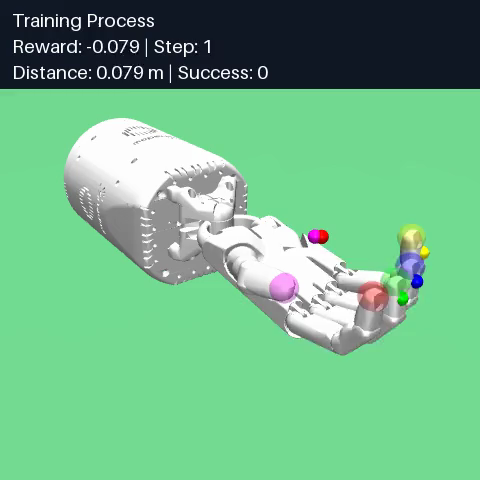

Smoke gates passed: training, checkpoint, reload, evaluation and MP4.


In [7]:
smoke_run_dir, smoke_metadata = train_model("smoke")
smoke_candidate = smoke_run_dir / "candidate.zip"
smoke_video = smoke_run_dir / "smoke.mp4"
smoke_policy = PPO.load(smoke_candidate, device=CONFIG["device"])
smoke_video_metadata = record_video(smoke_policy, smoke_video, "Training Process",
                                   {"run_id": smoke_metadata["run_id"], "timesteps": smoke_metadata["total_timesteps"]})
reader = imageio.get_reader(smoke_video)
try:
    assert reader.count_frames() == 50
    assert reader.get_meta_data()["fps"] == CONFIG["video_fps"]
    display(Image.fromarray(reader.get_data(0)))
finally:
    reader.close()
del smoke_policy
SMOKE_PASSED = True
print("Smoke gates passed: training, checkpoint, reload, evaluation and MP4.")


In [8]:
if CONFIG["profile"] == "full":
    assert SMOKE_PASSED, "Run all smoke gates before full training."
    full_run_dir, full_metadata = train_model("full")
    assert full_metadata["total_timesteps"] >= CONFIG["profiles"]["full"]["timesteps"]
    assert full_metadata["training_seconds"] > 0
    assert (full_run_dir / "candidate.zip").is_file()
    monitoring = pd.read_csv(full_run_dir / "tuning.csv")
    assert set(monitoring["seed"]) == set(CONFIG["tuning_seeds"])
    assert np.isfinite(monitoring[["episode_return", "final_goal_distance", "success_fraction"]]).all().all()
    milestones = monitoring[monitoring["timesteps"].isin([250_000, 500_000, 750_000, 1_000_000])]
    display(milestones.groupby("timesteps")[["episode_return", "success_final", "success_fraction", "final_goal_distance"]].mean())
    checkpoint = full_run_dir / "checkpoints" / f"checkpoint_{CONFIG['intermediate_timesteps']}.zip"
    intermediate = PPO.load(checkpoint, device=CONFIG["device"])
    assert intermediate.num_timesteps == CONFIG["intermediate_timesteps"]
    del intermediate
    # Durable compact evidence; bulky candidates/replay remain in ignored runs/.
    import shutil
    for filename in ("training.monitor.csv", "tuning.csv", "run.json", "reload_evaluation.csv", "progress.csv"):
        shutil.copy2(full_run_dir / filename, RESULTS_DIR / ("baseline_" + filename))
else:
    print("Smoke profile: full training and canonical delivery skipped.")


{
  "run_id": "20260912T131408120244Z_full",
  "profile": "full",
  "environment_id": "HandReachDense-v3",
  "algorithm": "PPO",
  "policy": "MultiInputPolicy",
  "seed": 42,
  "total_timesteps": 1001472,
  "optimization_epochs": 4890,
  "requested_timesteps": 1000000,
  "configuration": {
    "env_id": "HandReachDense-v3",
    "algorithm": "PPO",
    "policy": "MultiInputPolicy",
    "profile": "full",
    "train_seed": 42,
    "device": "cpu",
    "torch_threads": 1,
    "baseline_seeds": [
      101,
      102,
      103,
      104,
      105,
      106,
      107,
      108,
      109,
      110,
      111,
      112,
      113,
      114,
      115,
      116,
      117,
      118,
      119,
      120
    ],
    "tuning_seeds": [
      201,
      202,
      203,
      204,
      205,
      206,
      207,
      208,
      209,
      210
    ],
    "selection_seeds": [
      201,
      202,
      203,
      204,
      205,
      206,
      207,
      208,
      209,
      210
    

,seed,goal_type,max_fingertip_error,finger_distance_ff,finger_distance_mf,finger_distance_rf,finger_distance_lf,finger_distance_th,action_mean_abs,action_saturation_fraction,episode_return,episode_length,success_any,success_final,success_fraction,time_to_first_success,min_goal_distance,final_goal_distance
0,401,thumb_finger_meet,0.077852,0.018916,0.077852,0.030137,0.020952,0.018152,0.845791,0.694,-4.189150,50,False,False,0.0,<NA>,0.067621,0.089975
1,402,thumb_finger_meet,0.055958,0.019422,0.013926,0.055958,0.026722,0.018903,0.847042,0.691,-3.485756,50,False,False,0.0,<NA>,0.048249,0.069093


,episode_return,success_final,success_fraction,final_goal_distance
timesteps,,,,
250000,-3.967427,0.0,0.0,0.081098
500000,-3.773692,0.0,0.0,0.079349
750000,-3.868549,0.0,0.0,0.081074
1000000,-3.732232,0.0,0.0,0.074657


### Tuning controlado

El baseline alcanzó 1.001.472 pasos sin éxito en tuning y se estancó alrededor de 0.075 m de error global. KL y clip fraction elevados motivan el primer ajuste: learning rate 3e-5 y clip range 0.1, manteniendo arquitectura, seeds, presupuesto y entorno. Se permite un máximo de dos ajustes; no se promueve un candidato por mejorar solo el retorno. Seeds finales siguen reservadas.

In [8]:
def summarize_candidate(run_dir, delta):
    """Evaluate one saved candidate on the common tuning seeds.

    Args:
        run_dir: Directory containing candidate.zip and run.json.
        delta: Explicit changes relative to baseline.

    Returns:
        One experiment summary row with success and geometric diagnostics.
    """
    metadata = json.loads((run_dir / "run.json").read_text())
    candidate = PPO.load(run_dir / "candidate.zip", device=CONFIG["device"])
    evaluation = evaluate_policy(candidate, CONFIG["selection_seeds"])
    evaluation.to_csv(run_dir / "selection_evaluation.csv", index=False)
    return {"run_id": metadata["run_id"], "delta_vs_baseline": delta,
            "seed": metadata["seed"], "timesteps": metadata["total_timesteps"],
            "training_seconds": metadata["training_seconds"],
            "reward_mean": float(evaluation["episode_return"].mean()),
            "reward_std": float(evaluation["episode_return"].std(ddof=1)),
            "success_final_rate": float(evaluation["success_final"].mean()),
            "success_fraction_mean": float(evaluation["success_fraction"].mean()),
            "final_goal_distance_mean": float(evaluation["final_goal_distance"].mean()),
            "max_fingertip_error": float(evaluation["max_fingertip_error"].mean())}


if CONFIG["profile"] == "full":
    assert not set(CONFIG["selection_seeds"]) & set(CONFIG["final_eval_seeds"])
    experiments = [summarize_candidate(full_run_dir, "baseline")]
    pd.DataFrame(experiments).to_csv(RESULTS_DIR / "experiments.csv", index=False)
    if experiments[0]["success_final_rate"] < CONFIG["target_success"]:
        CONFIG["ppo"].update(CONFIG["tuning_adjustment_1"])
        tuning1_run_dir, tuning1_metadata = train_model("full")
        experiments.append(summarize_candidate(tuning1_run_dir, "learning_rate=3e-5; clip_range=0.1"))
        pd.DataFrame(experiments).to_csv(RESULTS_DIR / "experiments.csv", index=False)
    display(pd.DataFrame(experiments))


{
  "run_id": "20260912T132818867368Z_full",
  "profile": "full",
  "environment_id": "HandReachDense-v3",
  "algorithm": "PPO",
  "policy": "MultiInputPolicy",
  "seed": 42,
  "total_timesteps": 1001472,
  "optimization_epochs": 4890,
  "requested_timesteps": 1000000,
  "configuration": {
    "env_id": "HandReachDense-v3",
    "algorithm": "PPO",
    "policy": "MultiInputPolicy",
    "profile": "full",
    "train_seed": 42,
    "device": "cpu",
    "torch_threads": 1,
    "baseline_seeds": [
      101,
      102,
      103,
      104,
      105,
      106,
      107,
      108,
      109,
      110,
      111,
      112,
      113,
      114,
      115,
      116,
      117,
      118,
      119,
      120
    ],
    "tuning_seeds": [
      201,
      202,
      203,
      204,
      205,
      206,
      207,
      208,
      209,
      210
    ],
    "selection_seeds": [
      201,
      202,
      203,
      204,
      205,
      206,
      207,
      208,
      209,
      210
    

,seed,goal_type,max_fingertip_error,finger_distance_ff,finger_distance_mf,finger_distance_rf,finger_distance_lf,finger_distance_th,action_mean_abs,action_saturation_fraction,episode_return,episode_length,success_any,success_final,success_fraction,time_to_first_success,min_goal_distance,final_goal_distance
0,401,thumb_finger_meet,0.075725,0.012256,0.075725,0.020722,0.011337,0.014884,0.775175,0.520,-3.795302,50,False,False,0.0,<NA>,0.066451,0.081633
1,402,thumb_finger_meet,0.052533,0.012263,0.007210,0.052533,0.011324,0.019772,0.774515,0.514,-3.321292,50,False,False,0.0,<NA>,0.056434,0.059002


,run_id,delta_vs_baseline,seed,timesteps,training_seconds,reward_mean,reward_std,success_final_rate,success_fraction_mean,final_goal_distance_mean,max_fingertip_error
0,20260912T131408120244Z_full,baseline,42,1001472,767.220044,-3.76569,0.398492,0.0,0.0,0.074902,0.063199
1,20260912T132818867368Z_full,learning_rate=3e-5; clip_range=0.1,42,1001472,776.042700,-3.50633,0.345624,0.0,0.0,0.070063,0.063536


El primer ajuste mejora moderadamente el retorno pero mantiene cero éxitos y dispersión cercana a 0.9. El segundo ajuste cambia solo `log_std_init` respecto de ese experimento: de 0 a −1 (desviación inicial de 1 a exp(−1)≈0.368). Es una perilla estándar de la distribución PPO, no ruido externo ni un extractor personalizado. Se mantienen learning rate 3e-5 y clipping 0.1. Cada corrida parte de cero con seed 42 y un millón de pasos solicitados.

In [9]:
if CONFIG["profile"] == "full":
    experiments_df = pd.read_csv(RESULTS_DIR / "experiments.csv")
    assert len(experiments_df) == 2
    CONFIG["ppo"].update(CONFIG["tuning_adjustment_1"])
    CONFIG["log_std_init"] = CONFIG["tuning_adjustment_2_log_std_init"]
    tuning2_run_dir, tuning2_metadata = train_model("full")
    # The candidate summary uses exactly the same ten tuning seeds.
    row = summarize_candidate(tuning2_run_dir, "learning_rate=3e-5; clip_range=0.1; log_std_init=-1")
    experiments_df = pd.concat([experiments_df, pd.DataFrame([row])], ignore_index=True)
    assert len(experiments_df) == 3
    experiments_df.to_csv(RESULTS_DIR / "experiments.csv", index=False)
    display(experiments_df)


{
  "run_id": "20260912T134202783944Z_full",
  "profile": "full",
  "environment_id": "HandReachDense-v3",
  "algorithm": "PPO",
  "policy": "MultiInputPolicy",
  "seed": 42,
  "total_timesteps": 1001472,
  "optimization_epochs": 4890,
  "requested_timesteps": 1000000,
  "configuration": {
    "env_id": "HandReachDense-v3",
    "algorithm": "PPO",
    "policy": "MultiInputPolicy",
    "profile": "full",
    "train_seed": 42,
    "device": "cpu",
    "torch_threads": 1,
    "baseline_seeds": [
      101,
      102,
      103,
      104,
      105,
      106,
      107,
      108,
      109,
      110,
      111,
      112,
      113,
      114,
      115,
      116,
      117,
      118,
      119,
      120
    ],
    "tuning_seeds": [
      201,
      202,
      203,
      204,
      205,
      206,
      207,
      208,
      209,
      210
    ],
    "selection_seeds": [
      201,
      202,
      203,
      204,
      205,
      206,
      207,
      208,
      209,
      210
    

,seed,goal_type,max_fingertip_error,finger_distance_ff,finger_distance_mf,finger_distance_rf,finger_distance_lf,finger_distance_th,action_mean_abs,action_saturation_fraction,episode_return,episode_length,success_any,success_final,success_fraction,time_to_first_success,min_goal_distance,final_goal_distance
0,401,thumb_finger_meet,0.061551,0.022486,0.061551,0.021039,0.019430,0.015001,0.236632,0.069,-3.700787,50,False,False,0.0,<NA>,0.071703,0.073071
1,402,thumb_finger_meet,0.054889,0.022373,0.014947,0.054889,0.019291,0.005520,0.236506,0.069,-3.273171,50,False,False,0.0,<NA>,0.064032,0.064337


,run_id,delta_vs_baseline,seed,timesteps,training_seconds,reward_mean,reward_std,success_final_rate,success_fraction_mean,final_goal_distance_mean,max_fingertip_error
0,20260912T131408120244Z_full,baseline,42,1001472,767.220044,-3.765690,0.398492,0.0,0.0,0.074902,0.063199
1,20260912T132818867368Z_full,learning_rate=3e-5; clip_range=0.1,42,1001472,776.042700,-3.506330,0.345624,0.0,0.0,0.070063,0.063536
2,20260912T134202783944Z_full,learning_rate=3e-5; clip_range=0.1; log_std_in...,42,1001472,777.751592,-3.403737,0.327958,0.0,0.0,0.067464,0.056382


### Estado de selección: bloqueado

Se completaron baseline y dos ajustes, todos con 0/10 éxitos en las mismas seeds 201–210. El mejor retorno es −3.404 ± 0.328, con distancia global final media 0.06746 m. No se alcanzó el criterio de selección de 80% ni el umbral físico de 0.01 m.

La tarea 7 permanece abierta. No se promueve ZIP canónico; las seeds finales 1001–1010 siguen reservadas. Los capítulos 4 y 5 quedan pendientes hasta refinar el plan y obtener un candidato adecuado. `results/experiments.csv` y los archivos `experiment_*` preservan resultados, configuración y diagnósticos; los pesos candidatos están en los directorios locales `runs/` identificados por run_id.

No se amplía a 2M: las evaluaciones tardías del último ajuste fluctúan alrededor de 0.067–0.068 m y no muestran éxitos. El siguiente experimento requiere un refinamiento explícito, no una reducción del umbral de éxito.

## Capítulo 4 — Métricas y gráficas

Pendiente de la tarea correspondiente.

## Capítulo 5 — Videos

Pendiente de la tarea correspondiente.